<img src="logoucm.png" style="height:150px">

<center style="color:#1B4F72"><br/><font size="6"><b>Técnicas de Simulación</b></font><br/>
<font size="4">Máster en Ingeniería Matemática — Universidad Complutense de Madrid</font></center>


<center><font size="5"><span style="color:#117864">
<b>Nombre y Apellidos: ____________________</b>
</span></font></center>


<center><font size="5"><b style="color:#1B4F72">Ejemplos de Cadenas de Markov</b></font></center>


In [ ]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams.update({'font.size': 13})
np.random.seed(42)


---
## 1. Recordatorio: Cadenas de Markov

En el notebook anterior vimos que una **DTMC** (cadena de Markov de tiempo discreto)
es un proceso estocástico $\{X_n\}_{n\geq 0}$ con espacio de estados discreto
$\mathcal{S} = \{1, 2, \ldots, M\}$ que satisface la **propiedad de Markov**:

$$P(X_{n+1}=j \mid X_n=i,\, X_{n-1},\ldots) = P(X_{n+1}=j \mid X_n=i) = p_{ij}$$

La **matriz de transición** $P = (p_{ij})$ verifica $p_{ij}\geq 0$ y $\sum_j p_{ij}=1$.

Una matriz de transición puede representarse como un **grafo dirigido** donde los
vértices son los estados y las aristas sus probabilidades de transición.


El siguiente grafo corresponde a un sistema de 4 estados con transiciones simétricas $1/2$:

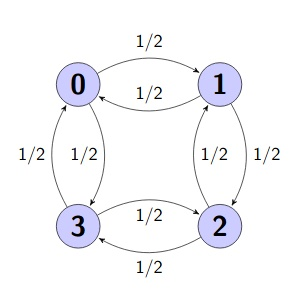


In [ ]:
# Reproducción del diagrama anterior con NetworkX
G = nx.DiGraph()
estados = [0, 1, 2, 3]
aristas = [(0,1,0.5),(1,0,0.5),(1,2,0.5),(2,1,0.5),(2,3,0.5),(3,2,0.5)]
G.add_nodes_from(estados)
G.add_weighted_edges_from(aristas)

pos = {0:(0,1), 1:(1,1), 2:(1,0), 3:(0,0)}
fig, ax = plt.subplots(figsize=(5,5))
nx.draw_networkx(G, pos=pos, ax=ax, node_color='#b0c4de',
                 node_size=900, font_size=14, font_weight='bold',
                 arrows=True, arrowsize=20)
edge_labels = {(u,v): f"{d['weight']:.1f}" for u,v,d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels, ax=ax, font_size=11)
ax.set_title("Grafo de transición — 4 estados simétricos", fontsize=13)
ax.axis('off')
plt.tight_layout(); plt.show()


---
## 2. Cadenas Reducibles e Irreducibles

Consideremos la **ruina del jugador**: una cadena en $\{0,1,2,3\}$ donde
los estados 0 y 3 son **absorbentes** (una vez alcanzados, no se puede salir).

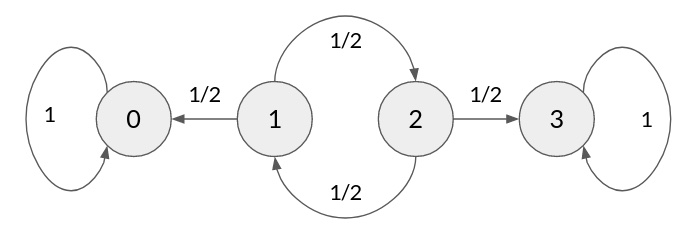

> **Definiciones:**
> - **Estado transitorio:** estado al que podríamos no retornar eventualmente.
> - **Estado recurrente:** estado al que siempre retornamos con probabilidad 1.
> - **Cadena reducible:** tiene al menos un estado transitorio.
> - **Cadena irreducible:** todos sus estados son recurrentes.

En este ejemplo, los estados 1 y 2 son **transitorios** y los estados 0 y 3 son
**recurrentes** (absorbentes). La cadena es **reducible**.

> **Nota:** Una cadena reducible puede descomponerse en subclases irreducibles.
> Aquí: $\{0\}$, $\{1,2\}$ (transitorios) y $\{3\}$.


In [ ]:
# Verificación numérica: estado transitorio vs recurrente
P_ruin = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.5, 0.0, 0.5, 0.0],
    [0.0, 0.5, 0.0, 0.5],
    [0.0, 0.0, 0.0, 1.0],
])

print("P^10:")
print(np.round(np.linalg.matrix_power(P_ruin, 10), 4))
print()
print("P^50:")
print(np.round(np.linalg.matrix_power(P_ruin, 50), 4))
print()
print("→ Los estados transitorios {1,2} se vacían; todo el peso acaba en {0} o {3}.")


---
## 3. Ejemplo: Predicción del Clima de Vigo

Modelamos el clima con dos estados: $s_A$ = Lluvioso, $s_B$ = Soleado.

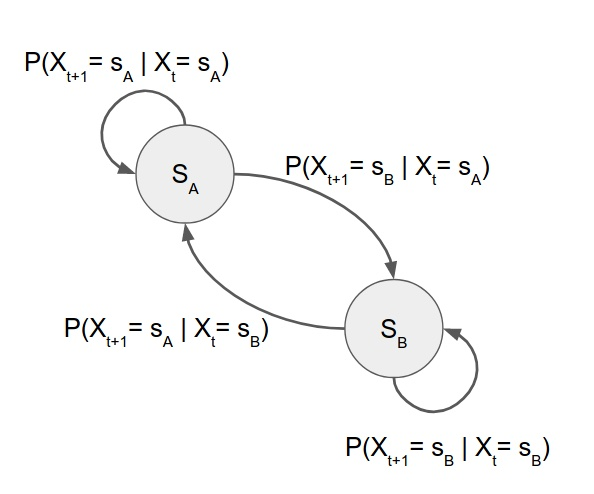

Las probabilidades de transición son:
$p_{AA} = 0.7,\; p_{AB} = 0.3,\; p_{BA} = 0.45,\; p_{BB} = 0.55$

$$P = \begin{pmatrix} 0.7 & 0.3 \\ 0.45 & 0.55 \end{pmatrix}$$

> **Pregunta:** Si hoy está **soleado**, ¿cuál es la probabilidad de lluvia mañana,
> en 3 días y en una semana?


In [ ]:
P = np.array([[0.70, 0.30],
              [0.45, 0.55]])

s0 = np.array([0, 1])   # estado inicial: soleado (s_B = índice 1)

print("Estado inicial s0 = [P(lluvia), P(sol)] =", s0)
print()
print("Distribución tras 1 paso  (mañana):  ", np.round(s0 @ P,   4))
print("Distribución tras 3 pasos (3 días):  ", np.round(s0 @ np.linalg.matrix_power(P, 3), 4))
print("Distribución tras 7 pasos (semana):  ", np.round(s0 @ np.linalg.matrix_power(P, 7), 4))
print("Distribución tras 1000 pasos (∞):    ", np.round(s0 @ np.linalg.matrix_power(P, 1000), 4))


---
## 4. Distribución Estacionaria

Un estado estacionario $\boldsymbol{\pi}$ satisface $\boldsymbol{\pi} P = \boldsymbol{\pi}$
y $\pi_A + \pi_B = 1$. Para el ejemplo del clima:

$$0.7\,\pi_A + 0.45\,\pi_B = \pi_A \;\Rightarrow\; 0.3\,\pi_A = 0.45\,\pi_B
\;\Rightarrow\; \pi_B = \tfrac{2}{3}\pi_A$$

Con $\pi_A + \pi_B = 1$: $\quad \pi_A = 0.6,\; \pi_B = 0.4$

Calculamos $\boldsymbol{\pi}$ de tres maneras para verificar la consistencia:


In [ ]:
# Método 1: potencia iterada
pi_iter = np.linalg.matrix_power(P, 1000)[0]

# Método 2: autovector izquierdo
eigenvalues, eigenvectors = np.linalg.eig(P.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))
pi_eig = np.real(eigenvectors[:, idx])
pi_eig /= pi_eig.sum()

# Método 3: sistema lineal (I - P^T) π = 0 con restricción suma=1
A = np.vstack([P.T - np.eye(2), np.ones(2)])
b = np.array([0, 0, 1])
pi_lin, *_ = np.linalg.lstsq(A, b, rcond=None)

print(f"{'Método':<25} {'π(lluvia)':>12} {'π(sol)':>10}")
print("-" * 50)
print(f"{'Potencia iterada':<25} {pi_iter[0]:>12.6f} {pi_iter[1]:>10.6f}")
print(f"{'Autovector':<25} {pi_eig[0]:>12.6f} {pi_eig[1]:>10.6f}")
print(f"{'Sistema lineal':<25} {pi_lin[0]:>12.6f} {pi_lin[1]:>10.6f}")
print(f"{'Teórico (0.6, 0.4)':<25} {'0.600000':>12} {'0.400000':>10}")
print()
print("Verificación π·P = π:", np.allclose(pi_iter @ P, pi_iter), "✓")


In [ ]:
# Visualización: convergencia desde distintos estados iniciales
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pasos = np.arange(0, 21)
for inicio, color, ls in [(np.array([1,0]),'steelblue','-'),
                           (np.array([0,1]),'coral','--')]:
    probs = np.array([inicio @ np.linalg.matrix_power(P, n) for n in pasos])
    label = "Inicio: Lluvioso" if inicio[0]==1 else "Inicio: Soleado"
    axes[0].plot(pasos, probs[:,0], color=color, ls=ls, lw=2, label=label)

axes[0].axhline(pi_iter[0], color='black', ls=':', lw=1.5, label=f'π(lluvia)={pi_iter[0]:.2f}')
axes[0].set_xlabel('Pasos $n$'); axes[0].set_ylabel('P(lluvia en paso n)')
axes[0].set_title('Convergencia a distribución estacionaria')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Grafo de transición
G = nx.DiGraph()
G.add_weighted_edges_from([('Lluvia','Lluvia',0.70),('Lluvia','Sol',0.30),
                            ('Sol','Lluvia',0.45),('Sol','Sol',0.55)])
pos = {'Lluvia':(0,0), 'Sol':(2,0)}
nx.draw_networkx(G, pos=pos, ax=axes[1], node_color=['#6baed6','#fd8d3c'],
                 node_size=2000, font_size=12, font_weight='bold', arrows=True, arrowsize=20)
edge_labels = {(u,v): f"{d['weight']}" for u,v,d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels, ax=axes[1], font_size=11)
axes[1].set_title('Grafo de transición del clima'); axes[1].axis('off')

plt.tight_layout(); plt.show()


---
## 5. Ejemplo: Cadena de 3 Estados — Probabilidades en $n$ Pasos

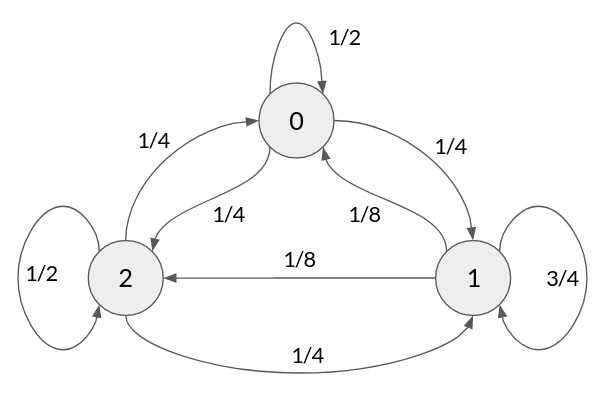

$$P = \begin{pmatrix} 1/2 & 1/4 & 1/4 \\ 1/8 & 3/4 & 1/8 \\ 1/4 & 1/4 & 1/2 \end{pmatrix}$$

> **Pregunta:** ¿Cuál es la probabilidad de llegar al estado 2 desde el estado 0 en 2 pasos?

$$[P^2]_{0,2} = \sum_k p_{0k}\, p_{k2} = p_{00}p_{02} + p_{01}p_{12} + p_{02}p_{22}$$


In [ ]:
P3 = np.array([[1/2, 1/4, 1/4],
               [1/8, 3/4, 1/8],
               [1/4, 1/4, 1/2]])

p02_2pasos = np.linalg.matrix_power(P3, 2)[0, 2]
print(f"P(X_2=2 | X_0=0) = [P²]_{{0,2}} = {p02_2pasos:.5f}")
print(f"Cálculo manual: {1/2*1/4 + 1/4*1/8 + 1/4*1/2:.5f}")
print()

print("Convergencia de P^n:")
for n in [1, 3, 5, 10, 50, 100]:
    Pn = np.linalg.matrix_power(P3, n)
    print(f"n={n:>3}: filas = {np.round(Pn[0],4)}, {np.round(Pn[1],4)}, {np.round(Pn[2],4)}")


> **Nota:** Las filas de $P^n$ convergen a $\boldsymbol{\pi}$ **solo si la cadena es
> irreducible** (todos los estados se comunican entre sí). En este caso, la cadena
> es irreducible porque existe un camino entre cualquier par de estados.


In [ ]:
# Distribución estacionaria de la cadena de 3 estados
eigenvalues, eigenvectors = np.linalg.eig(P3.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))
pi3 = np.real(eigenvectors[:, idx]); pi3 /= pi3.sum()
print("Distribución estacionaria π:", np.round(pi3, 6))
print("Verificación π·P = π:", np.allclose(pi3 @ P3, pi3), "✓")
print("Coincide con P^100 fila 0:", np.allclose(pi3, np.linalg.matrix_power(P3,100)[0]), "✓")


---
## 6. Algoritmo de Simulación y Ley Ergódica

Para simular una DTMC con estados discretos usamos muestreo multinomial:

1. Fijar $n=0$ y estado inicial $X_0 = i$
2. Para $n = 1, 2, \ldots, T$:  
   - Tomar la fila $P[X_n, :]$  
   - Muestrear $X_{n+1} \sim \text{Multinomial}(1, P[X_n,:])$

### Muestreo multinomial con NumPy


In [ ]:
np.random.seed(12345)
fila_ejemplo = [0.7, 0.2, 0.1]

print("3 muestras de Multinomial(1, [0.7, 0.2, 0.1]):")
for _ in range(3):
    muestra = scipy.stats.multinomial.rvs(n=1, p=fila_ejemplo, size=1)
    estado  = np.argmax(muestra)
    print(f"  vector one-hot: {muestra[0]}  → estado: {estado}")

# Histograma de 1000 muestras
x = np.array([np.argmax(np.random.multinomial(1, fila_ejemplo)) for _ in range(1000)])
fig, ax = plt.subplots(figsize=(5,3))
ax.bar([0,1,2], [np.mean(x==s) for s in [0,1,2]],
       color=['steelblue','coral','green'], edgecolor='black', alpha=0.85)
ax.bar([0,1,2], fila_ejemplo, alpha=0.3, color='black', label='Prob. teórica')
ax.set_xticks([0,1,2]); ax.set_xlabel('Estado'); ax.set_ylabel('Frecuencia relativa')
ax.set_title('1000 muestras vs probabilidades teóricas [0.7, 0.2, 0.1]')
ax.legend(); plt.tight_layout(); plt.show()


### Simulación del ejemplo del clima — 1000 cadenas


In [ ]:
np.random.seed(42)
P_clima = np.array([[0.70, 0.30],
                    [0.45, 0.55]])

n_chains, horizon = 1000, 20
states = np.zeros((n_chains, horizon+1), dtype=int)
states[:, 0] = 1   # todos parten del estado 1 (soleado)

for i in range(n_chains):
    for j in range(1, horizon+1):
        states[i, j] = np.random.choice(2, p=P_clima[states[i,j-1],:])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Tres trayectorias individuales
for i in range(3):
    axes[0].step(range(horizon+1), states[i,:], where='post',
                 lw=2, alpha=0.8, label=f'Cadena {i+1}')
axes[0].set_yticks([0,1]); axes[0].set_yticklabels(['Lluvia','Sol'])
axes[0].set_xlabel('Paso $n$'); axes[0].set_title('3 trayectorias individuales')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Evolución de probabilidades empíricas
pi_clima = np.linalg.matrix_power(P_clima, 1000)[0]
hist = np.array([[np.mean(states[:,j]==s) for s in [0,1]] for j in range(horizon+1)])
axes[1].plot(hist[:,0], color='steelblue', lw=2, label='P(lluvia) empírica')
axes[1].plot(hist[:,1], color='coral',     lw=2, label='P(sol) empírica')
axes[1].axhline(pi_clima[0], color='steelblue', ls='--', lw=1, label=f'π(lluvia)={pi_clima[0]:.2f}')
axes[1].axhline(pi_clima[1], color='coral',     ls='--', lw=1, label=f'π(sol)={pi_clima[1]:.2f}')
axes[1].set_xlabel('Paso $n$'); axes[1].set_ylabel('Probabilidad empírica')
axes[1].set_title('Convergencia empírica a π (1000 cadenas)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


---
## 7. Ley Ergódica para Cadenas de Markov

Para variables i.i.d. la ley de los grandes números dice:
$$\lim_{N\to\infty} \frac{1}{N}\sum_{i=1}^N X_i = \mu$$

Para cadenas de Markov **irreducibles y aperiódicas** existe un resultado análogo,
el **teorema ergódico**:

$$\lim_{N\to\infty} \frac{1}{N}\sum_{n=0}^{N-1} \mathbf{1}\{X_n = j\} = \pi_j \quad \text{(c.s.)}$$

Es decir, la **fracción de tiempo** que la cadena pasa en el estado $j$ converge
a $\pi_j$, independientemente del estado inicial.

> **Nota:** $\pi_j = 1/m_j$ donde $m_j = \mathbb{E}_j[T_j]$ es el tiempo medio
> de retorno al estado $j$ — conexión directa con la clasificación de estados.


In [ ]:
np.random.seed(42)
P_clima = np.array([[0.70, 0.30],
                    [0.45, 0.55]])
pi_clima = np.linalg.matrix_power(P_clima, 1000)[0]

# Una trayectoria muy larga
T_largo = 5000
estado  = 1   # inicio soleado
trayectoria_larga = [estado]
for _ in range(T_largo):
    estado = np.random.choice(len(P_clima), p=P_clima[estado,:])
    trayectoria_larga.append(estado)

tray = np.array(trayectoria_larga)
frec_acum_lluvia = np.cumsum(tray == 0) / np.arange(1, len(tray)+1)
frec_acum_sol    = np.cumsum(tray == 1) / np.arange(1, len(tray)+1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(frec_acum_lluvia, color='steelblue', lw=1.5, label='Frec. acumulada lluvia')
ax.plot(frec_acum_sol,    color='coral',     lw=1.5, label='Frec. acumulada sol')
ax.axhline(pi_clima[0], color='steelblue', ls='--', lw=1.5, label=f'π(lluvia) = {pi_clima[0]:.2f}')
ax.axhline(pi_clima[1], color='coral',     ls='--', lw=1.5, label=f'π(sol)    = {pi_clima[1]:.2f}')
ax.set_xlabel('Número de pasos $n$'); ax.set_ylabel('Frecuencia acumulada')
ax.set_title('Ley ergódica: la frecuencia acumulada converge a $\pi$')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Fracción final en lluvia: {frec_acum_lluvia[-1]:.4f}  (π={pi_clima[0]:.4f})")
print(f"Fracción final en sol:    {frec_acum_sol[-1]:.4f}  (π={pi_clima[1]:.4f})")
print(f"Tiempo medio de retorno a lluvia: m_A = 1/π_A = {1/pi_clima[0]:.3f} pasos")


---
## Resumen

| Concepto | Resultado |
|---|---|
| Distribución estacionaria $\pi$ | $\pi P = \pi$, $\sum_j \pi_j = 1$ |
| Cálculo de $\pi$ | Autovector izquierdo de $P$ (autovalor 1) |
| Convergencia $P^n \to \pi$ | Solo si la cadena es irreducible y aperiódica |
| Ley ergódica | Frec. acumulada en estado $j$ $\to \pi_j$ |
| Tiempo medio retorno | $m_j = 1/\pi_j$ |
| Estados absorbentes | $p_{ii}=1$: recurrentes positivos, $m_i=1$ |
| Cadena reducible | Tiene estados transitorios y recurrentes |
